<a href="https://colab.research.google.com/github/Blecyrajan/Dissertation/blob/main/BrainTumor_CNN_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Downloading dataset




In [1]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


# 2. Install required libraries

In [2]:
!pip install torch torchvision opencv-python matplotlib tqdm scikit-learn

## 3. Import required libraries

In [3]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 3. Dataset path






In [4]:
DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

In [5]:
os.listdir(DATASET_PATH)

['Training', 'Testing']

In [6]:
TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH  = os.path.join(DATASET_PATH, "Testing")

print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

Train folders: ['pituitary', 'notumor', 'meningioma', 'glioma']
Test folders: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [7]:
print("Dataset root:", os.listdir(DATASET_PATH))
print("\nTraining classes:", os.listdir(os.path.join(DATASET_PATH, "Training")))
print("\nTesting classes:", os.listdir(os.path.join(DATASET_PATH, "Testing")))


Dataset root: ['Training', 'Testing']

Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']

Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


# 4. Sample brain MRI

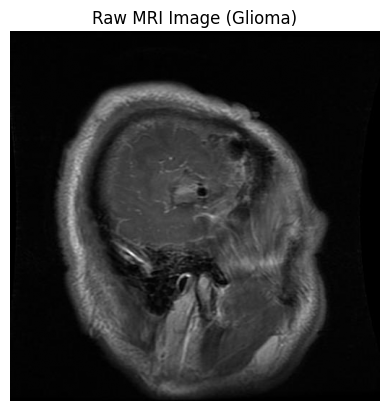

In [8]:
sample_class = "glioma"
sample_image = os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]

img_path = os.path.join(TRAIN_PATH, sample_class, sample_image)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Raw MRI Image (Glioma)")
plt.axis("off")
plt.show()


# DEFINE OUTPUT DIRECTORY

In [9]:
PROCESSED_ROOT = "/content/Processed_Dataset"

PROCESSED_TRAIN = os.path.join(PROCESSED_ROOT, "Training")
PROCESSED_TEST  = os.path.join(PROCESSED_ROOT, "Testing")

os.makedirs(PROCESSED_TRAIN, exist_ok=True)
os.makedirs(PROCESSED_TEST, exist_ok=True)

print("Processed folders created")


Processed folders created


# PROCESS & SAVE IMAGES

In [10]:
IMG_SIZE = 224
def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) #resize to 224 x 224
    img = img / 255.0 #pixels are normalized

    # convert grayscale -> 3 channel
    img = np.stack([img, img, img], axis=-1)

    return img

In [11]:
def preprocess_and_save(input_root, output_root):
    classes = ["glioma", "meningioma", "pituitary", "notumor"]

    for cls in classes:
        input_cls_dir = os.path.join(input_root, cls)
        output_cls_dir = os.path.join(output_root, cls)

        os.makedirs(output_cls_dir, exist_ok=True)

        for img_name in os.listdir(input_cls_dir):
            img_path = os.path.join(input_cls_dir, img_name)

            img = preprocess_image(img_path)

            # convert back to uint8 for saving
            img_uint8 = (img * 255).astype(np.uint8)

            save_path = os.path.join(output_cls_dir, img_name)
            cv2.imwrite(save_path, img_uint8)

        print(f"Saved preprocessed images for class: {cls}")


# PREPROCESS & SAVE TRAINING DATA

In [12]:
preprocess_and_save(TRAIN_PATH, PROCESSED_TRAIN)

Saved preprocessed images for class: glioma
Saved preprocessed images for class: meningioma
Saved preprocessed images for class: pituitary
Saved preprocessed images for class: notumor


# PREPROCESS & SAVE TESTING DATA

In [13]:
preprocess_and_save(TEST_PATH, PROCESSED_TEST)

Saved preprocessed images for class: glioma
Saved preprocessed images for class: meningioma
Saved preprocessed images for class: pituitary
Saved preprocessed images for class: notumor


# VERIFY SAVED FILES

In [14]:
print("Processed Training folders:", os.listdir(PROCESSED_TRAIN))
print("Sample images in glioma:",
      os.listdir(os.path.join(PROCESSED_TRAIN, "glioma"))[:5])


Processed Training folders: ['meningioma', 'notumor', 'pituitary', 'glioma']
Sample images in glioma: ['Tr-gl_0930.jpg', 'Tr-gl_1017.jpg', 'Tr-gl_1137.jpg', 'Tr-gl_1052.jpg', 'Tr-gl_1207.jpg']


# VISUAL CHECK (RAW vs SAVED PROCESSED)

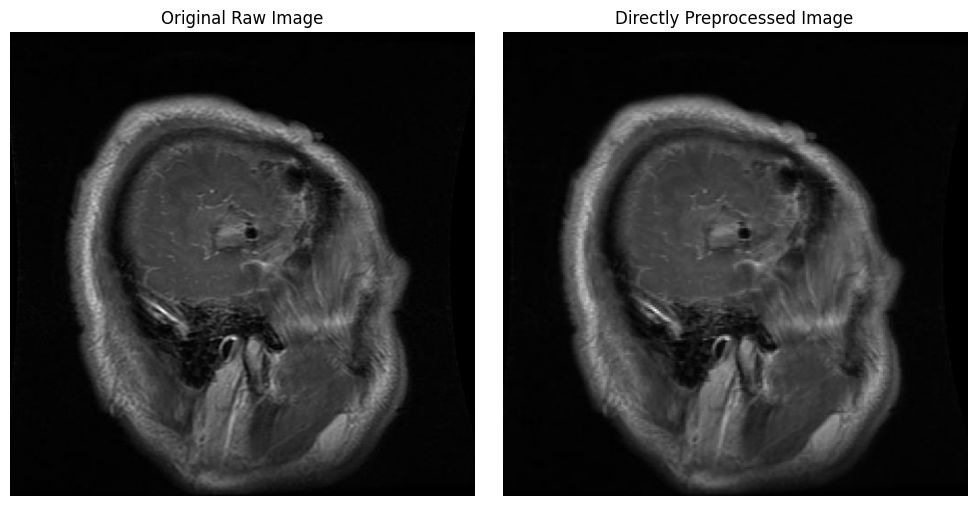

In [15]:
sample_class = "glioma"
sample_image_name = os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]

# Get the full path for the raw image
raw_img_path = os.path.join(TRAIN_PATH, sample_class, sample_image_name)

# Load the raw image
raw_img = cv2.imread(raw_img_path, cv2.IMREAD_GRAYSCALE)

# Preprocess the *same* image using the defined function
# The preprocess_image function returns a normalized 3-channel image
processed_img_direct = preprocess_image(raw_img_path)

# For displaying with plt.imshow, if processed_img_direct is normalized (0-1),
# it will be displayed correctly. If we want to show it as grayscale uint8,
# we might need to convert it back to single channel and scale.
# However, imshow can handle float arrays directly.
# To show it as grayscale for direct comparison with `raw_img` (which is 1 channel gray),
# we can take one channel from the 3-channel processed image and scale it back to 0-255 for clarity if needed.
# Or, as preprocess_image outputs normalized float, imshow will handle it fine.

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Raw Image")
plt.imshow(raw_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Directly Preprocessed Image")
# Displaying one channel of the 3-channel normalized image, scaled back to 0-255 if desired.
# Or directly display the normalized float array, matplotlib handles it.
plt.imshow(processed_img_direct[:,:,0], cmap="gray") # Taking one channel for grayscale display
plt.axis("off")

plt.tight_layout()
plt.show()

# UPDATE DATASET CLASS TO USE PROCESSED DATA

In [16]:
class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.class_map = {
            "glioma": 0,
            "meningioma": 1,
            "pituitary": 2,
            "notumor": 3
        }

        for cls in self.class_map:
            cls_dir = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_dir):
                self.samples.append(
                    (os.path.join(cls_dir, img_name), self.class_map[cls])
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = cv2.imread(img_path)
        img = img / 255.0
        img = torch.tensor(img).permute(2, 0, 1).float()

        return img, label


In [17]:
train_dataset = MRIDataset(PROCESSED_TRAIN)
test_dataset  = MRIDataset(PROCESSED_TEST)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train batches ready:", len(train_loader))


Train batches ready: 714


# PHASE 2 — CNN–ViT MODEL

# Confirm GPU

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


# CNN feature extractor

In [19]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.layer1(x)   # (B, 32, 112, 112)
        x = self.layer2(x)   # (B, 64, 56, 56)
        x = self.layer3(x)   # (B, 128, 56, 56)
        return x


In [20]:
cnn = CNNEncoder().to(device)

images, _ = next(iter(train_loader))
images = images.to(device)

cnn_features = cnn(images)
print("CNN output shape:", cnn_features.shape)


CNN output shape: torch.Size([8, 128, 56, 56])


# Patch embedding (CNN-ViT bridge)

In [21]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.projection = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=4,
            stride=4
        )

    def forward(self, x):
        x = self.projection(x)   # (B, 256, 14, 14)
        x = x.flatten(2)         # (B, 256, 196)
        x = x.transpose(1, 2)    # (B, 196, 256)
        return x


In [22]:
patch = PatchEmbedding().to(device)

tokens = patch(cnn_features)
print("Patch tokens shape:", tokens.shape)


Patch tokens shape: torch.Size([8, 196, 256])


# Vision Transformer Encoder

In [23]:
class ViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

    def forward(self, x):
        return self.encoder(x)


In [24]:
vit = ViTEncoder().to(device)

vit_out = vit(tokens)
print("ViT output shape:", vit_out.shape)


ViT output shape: torch.Size([8, 196, 256])


# CNN-ViT

In [25]:
class CNN_ViT(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.cnn = CNNEncoder()
        self.patch = PatchEmbedding()
        self.vit = ViTEncoder()
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        cnn_features = self.cnn(x)
        tokens = self.patch(cnn_features)
        vit_out = self.vit(tokens)

        pooled = vit_out.mean(dim=1)
        logits = self.classifier(pooled)

        return logits, cnn_features


In [26]:
model = CNN_ViT().to(device)

logits, features = model(images)

print("Logits shape:", logits.shape)
print("CNN feature shape:", features.shape)


Logits shape: torch.Size([8, 4])
CNN feature shape: torch.Size([8, 128, 56, 56])
